In [ ]:
#Step 1 Import the data and to get ride of scientific notation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format='{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

In [ ]:
# 2: Display the raw data to amke sure it looks right
display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
# Step 3: View the correlation between the variables to see which ones relate to reveneu

HS_data.loc[:, ['revenue', 'production', 'coolDD', 'heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


In [ ]:
# Step 4: separte the rows into training data and testing data

dt4training = HS_data.loc[HS_data['type'] == 'dt4training']
dt4testing = HS_data.loc[HS_data['type'] == 'dt4testing']

print(f"Training rows: {len(dt4training)}")
print(f"Testing rows: {len(dt4testing)}")
display(dt4training.head())

Training rows: 36
Testing rows: 12


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114


In [ ]:
# amke a revenue vs production regression with training data

import statsmodels.api as sm


y = dt4training.loc[:, 'revenue']

x1 = dt4training.loc[:, 'production']
x1 = sm.add_constant(x1)

model1 = sm.OLS(y, x1).fit()
model1.summary()

model1.params


,0
const,4897663.26
production,18.99


In [ ]:
# Model 1: predict testing revenue and measure average percentage error

x1_test = dt4testing.loc[:, 'production']
x1_test = sm.add_constant(x1_test)

model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x1_test)
model1_assessment['model1_pctError'] = abs(
    model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
) / model1_assessment['revenue']

display(model1_assessment)

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [ ]:
# apart of step above

mape1 = model1_assessment['model1_pctError'].mean()
print(f"Model 1 (production) MAPE: {mape1:.2%}")

Model 1 (production) MAPE: 25.42%


In [ ]:
# Model 2: predict testing revenue and coolDD average percentage

x2 = dt4training.loc[:, 'coolDD']
x2 = sm.add_constant(x2)

model2 = sm.OLS(y, x2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.5883
Date:                Fri, 10 Jul 2026   Prob (F-statistic):              0.448
Time:                        21:47:00   Log-Likelihood:                -607.10
No. Observations:                  36   AIC:                             1218.
Df Residuals:                      34   BIC:                             1221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.434e+07   1.08e+06     13.275      0.000    1.21e+07    1.65e+07
coolDD     -4113.9355   5363.430     -0.767      0.448    -1.5e+04    6785.866
==============================================================================
Omnibus:                        0.850   Durbin-Watson:                   0.964
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.822
Skew:                           0.142   Prob(JB):                        0.663
Kurtosis:                       2.317   Cond. No.                         249.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
model2.params

,0
const,14341632.04
coolDD,-4113.94


In [ ]:
# Model 2: predict testing revenue and measure average percentage error

x2_test = dt4testing.loc[:, 'coolDD']
x2_test = sm.add_constant(x2_test)

model2_assessment = dt4testing.copy()
model2_assessment['model2_predicted_revenue'] = model2.predict(x2_test)
model2_assessment['model2_pctError'] = abs(
    model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']
) / model2_assessment['revenue']

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,0.52


In [ ]:
mape2 = model2_assessment['model2_pctError'].mean()
print(f"Model 2 (coolDD) MAPE: {mape2:.2%}")

Model 2 (coolDD) MAPE: 29.60%


In [ ]:
# Make a comparison Table

comparison = pd.DataFrame({
    'Model': ['Model 1 (production)', 'Model 2 (coolDD)'],
    'MAPE': [mape1, mape2],
    'R-squared (training)': [model1.rsquared, model2.rsquared],
    'p-value (feature)': [model1.pvalues['production'], model2.pvalues['coolDD']]
})
comparison['MAPE'] = comparison['MAPE'].map('{:.2%}'.format)
comparison['R-squared (training)'] = comparison['R-squared (training)'].map('{:.3f}'.format)
comparison['p-value (feature)'] = comparison['p-value (feature)'].map('{:.3f}'.format)
display(comparison)

,Model,MAPE,R-squared (training),p-value (feature)
0,Model 1 (production),25.42%,0.397,0.000
1,Model 2 (coolDD),29.60%,0.017,0.448


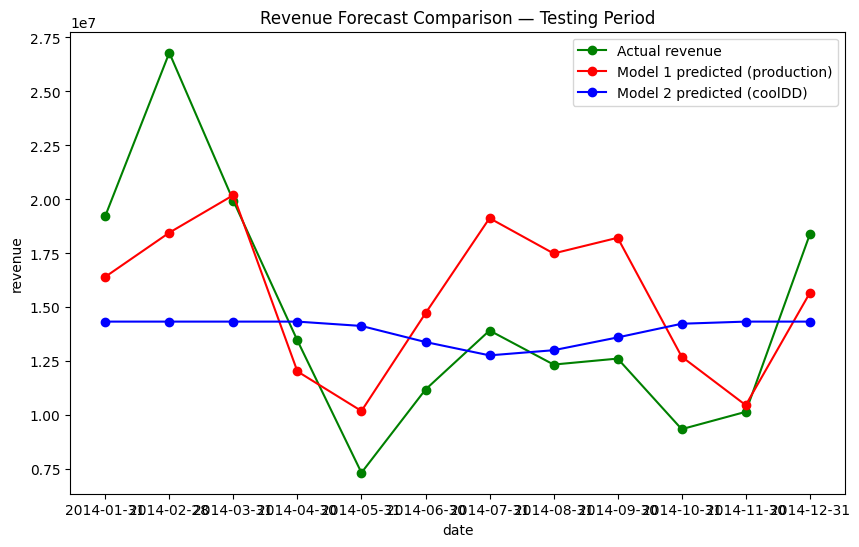

In [ ]:
# Make a visualization

plt.figure(figsize=(10,6))

plt.title('Revenue Forecast Comparison — Testing Period')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color='green', label='Actual revenue')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color='red', label='Model 1 predicted (production)')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'], marker='o', color='blue', label='Model 2 predicted (coolDD)')

plt.legend()
plt.show()


I found model 1 (revenue/production) outperforms Model 2 (revenue/coolDD) since model 1 has a lower MAPE, it is better at predicting accuracy. We recommend using Model 1 for forecasting even though the error rate is still above the 12-15% is the range for a good MAPE percentage.